# Bike Rental Demand — Ridge Regression Baseline

A regularized linear baseline for daily rental demand. This notebook preserves the original preprocessing, cross-validation, tuning and residual analysis used to establish a benchmark before moving to nonlinear models.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**IMPORTS**


In [130]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas
from IPython.display import display, HTML
%matplotlib inline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import warnings

from sklearn.model_selection import BaseCrossValidator
from sklearn.utils.validation import _num_samples


**CONSTANTS**


In [133]:
FILE_PATH = 'data/bike_output.csv'


**OPTIONS**


**METHODS**


In [139]:
import numpy as np
import pandas as pd
from sklearn.model_selection import BaseCrossValidator
from sklearn.utils.validation import _num_samples
import warnings

class ExpandingWindowSplitRemainderTest(BaseCrossValidator):
    """
    Expanding Window Cross-Validator: Test on All Remaining Data.

    Splits the data into training and test sets based on sorted month periods.
    The training set size expands in each split. The test set consists of *all*
    data chronologically after the training set (plus any specified gap).

    Includes verbose printing during split generation.

    Parameters
    ----------
    month_series : pd.Series
        A pandas Series where the index corresponds to the sample index in X/y,
        and the values are comparable month identifiers (e.g., pd.Period, 'YYYY-MM').
        Must contain sorted unique months reflecting chronology.

    initial_train_months : int
        The number of months to include in the first training split.

    expansion_step_months : int, default=1
        The number of months by which the training set expands for the *next* fold.
        Typically set to the desired frequency of model retraining/evaluation (e.g., 1 for monthly).

    gap_months : int, default=0
        The number of months to skip between the end of the training set
        and the beginning of the test set.

    max_splits : int or None, default=None
        The maximum number of splits to generate. If None, all possible splits
        according to the parameters will be generated.

    verbose : bool, default=True
        If True, prints details about each fold during the split process.

    Attributes
    ----------
    unique_months_ : np.ndarray
        Sorted unique month values found in `month_series`.

    n_splits_ : int
        The number of splits generated.
    """
    def __init__(self, month_series, initial_train_months, expansion_step_months=1,
                 gap_months=0, max_splits=None, verbose=True): # Renamed test_months
        if not isinstance(month_series, pd.Series):
            raise ValueError("month_series must be a pandas Series.")
        if initial_train_months < 1:
            raise ValueError("initial_train_months must be at least 1.")
        if expansion_step_months < 1: # Check expansion step
            raise ValueError("expansion_step_months must be at least 1.")
        if gap_months < 0:
            raise ValueError("gap_months cannot be negative.")

        self.month_series = month_series
        self.initial_train_months = initial_train_months
        self.expansion_step_months = expansion_step_months # Store expansion step
        self.gap_months = gap_months
        self.max_splits = max_splits
        self.verbose = verbose

        # Store unique sorted months
        self.unique_months_ = np.sort(month_series.unique())
        self.n_total_months_ = len(self.unique_months_)

        # Check if ANY test data is possible for the first split
        first_test_start_idx = self.initial_train_months + self.gap_months
        if first_test_start_idx >= self.n_total_months_:
             raise ValueError(
                 f"Not enough months ({self.n_total_months_}) for any test data "
                 f"with initial_train_months={initial_train_months} and "
                 f"gap_months={gap_months}. Need at least {first_test_start_idx + 1} months."
             )

        # Pre-calculate the number of splits
        self.n_splits_ = self._calculate_n_splits()
        if self.verbose:
            print(f"ExpandingWindowSplitRemainderTest initialized: Found {self.n_total_months_} unique months.")
            print(f"Calculated {self.n_splits_} possible splits based on parameters.")

    def _calculate_n_splits(self):
        """Calculates the total number of splits possible."""
        max_possible_splits = 0
        current_train_end_idx = self.initial_train_months
        while True:
            # Test data starts after train + gap
            test_start_idx = current_train_end_idx + self.gap_months
            # A split is possible as long as there's at least one month for testing
            if test_start_idx < self.n_total_months_:
                max_possible_splits += 1
                # Training data expands by the step size for the next potential split
                current_train_end_idx += self.expansion_step_months
            else:
                break # Cannot form another split (no test data possible)

        if self.max_splits is not None:
            return min(max_possible_splits, self.max_splits)
        else:
            return max_possible_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        """Returns the number of splitting iterations in the cross-validator."""
        return self.n_splits_

    def split(self, X, y=None, groups=None):
        """Generate indices to split data into training and test set."""
        n_samples = _num_samples(X)
        # Index handling (same as previous version)
        if isinstance(X, pd.DataFrame) and X.index.equals(self.month_series.index):
             indices = self.month_series.index.to_numpy()
        elif isinstance(X, pd.Series) and X.index.equals(self.month_series.index):
             indices = self.month_series.index.to_numpy()
        else:
             if n_samples != len(self.month_series):
                 warnings.warn(f"Number of samples in X ({n_samples}) differs from "
                               f"length of month_series ({len(self.month_series)}). "
                               f"Ensure month_series corresponds row-wise to X.")
             indices = np.arange(n_samples)

        current_train_end_idx = self.initial_train_months
        splits_generated = 0

        while splits_generated < self.n_splits_:
            fold_num = splits_generated + 1
            test_start_idx = current_train_end_idx + self.gap_months
            # Test end is ALWAYS the end of the data
            test_end_idx = self.n_total_months_

            # Boundary check: Ensure test_start_idx is valid
            if test_start_idx >= self.n_total_months_:
                if self.verbose:
                    print(f"Stopping split generation: Cannot form test set starting at index {test_start_idx} "
                          f"with total months {self.n_total_months_}")
                break

            train_months = self.unique_months_[0:current_train_end_idx]
            test_months_fold = self.unique_months_[test_start_idx:test_end_idx]

            # Get boolean masks
            train_mask = self.month_series.isin(train_months)
            test_mask = self.month_series.isin(test_months_fold)

            # Select indices
            train_idx = indices[train_mask.to_numpy(dtype=bool)]
            test_idx = indices[test_mask.to_numpy(dtype=bool)]

            if self.verbose:
                print(f"\n--- Fold {fold_num}/{self.n_splits_} ---")
                print(f"  Train months ({len(train_months)}): {train_months[0]} to {train_months[-1]}")
                if len(test_months_fold) > 0:
                    print(f"  Test months  ({len(test_months_fold)}): {test_months_fold[0]} to {test_months_fold[-1]} (Remainder)")
                else:
                    print(f"  Test months  (0): None (Should not happen with checks)") # Should not happen if checks are right
                print(f"  Train indices: {len(train_idx)}")
                print(f"  Test indices : {len(test_idx)}")

            if len(test_idx) == 0 and len(test_months_fold) > 0 :
                 warnings.warn(f"Fold {fold_num}: Test set is empty despite having test months "
                               f"{test_months_fold}. Check data alignment.", UserWarning)
            if len(train_idx) == 0:
                 warnings.warn(f"Fold {fold_num}: Train set is empty for months "
                               f"{train_months}. Check initial_train_months.", UserWarning)

            yield train_idx, test_idx

            # Expand the training window for the next iteration by the step size
            current_train_end_idx += self.expansion_step_months
            splits_generated += 1


**LOAD DATA**


In [142]:
df_bike_model = pd.read_csv(FILE_PATH)
df_bike_model['dteday'] = pd.to_datetime(df_bike_model['dteday'])
df_bike_model.sort_values('dteday', inplace=True)


In [144]:
df_bike_model.tail()


,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt
726,727,2012-12-27,1,1,12,0,4.0,1,2,0.226642,0.652917,0.350133,2114
727,728,2012-12-28,1,1,12,0,5.0,1,2,0.255046,0.590000,0.155471,3095
728,729,2012-12-29,1,1,12,0,6.0,0,2,0.242400,0.752917,0.124383,1341
729,730,2012-12-30,1,1,12,0,0.0,0,1,0.231700,0.483333,0.350754,1796
730,731,2012-12-31,1,1,12,0,1.0,1,2,0.223487,0.577500,0.154846,2729


**PREPARING DATA FOR MODELING**


In [147]:
# Create the 'year_month' column as before
df_bike_model['year_month'] = df_bike_model['dteday'].dt.to_period('M')
month_series = df_bike_model['year_month'] # Ensure index matches X

df_bike_model['time_idx'] = df_bike_model.index

# --- Add Cyclical Encoding for Monthly Cycles ---
df_bike_model['mnth_sin'] = np.sin(2 * np.pi * df_bike_model['mnth'] / 12)
df_bike_model['mnth_cos'] = np.cos(2 * np.pi * df_bike_model['mnth'] / 12)

"""
# --- Add Cyclical Encoding for Weekly Cycles ---
# (Extract weekday from 'dteday' if necessary)
df_bike_model['weekday'] = pd.to_datetime(df_bike_model['dteday']).dt.weekday
df_bike_model['weekday_sin'] = np.sin(2 * np.pi * df_bike_model['weekday'] / 7)
df_bike_model['weekday_cos'] = np.cos(2 * np.pi * df_bike_model['weekday'] / 7)
"""

# --- Add Previous Day Information (Lag Feature) ---
df_bike_model['cnt_lag2'] = df_bike_model['cnt'].shift(2) 
df_bike_model['hum_lag2'] = df_bike_model['hum'].shift(2)
df_bike_model['atemp_lag2'] = df_bike_model['atemp'].shift(2)
# since at 3pm I don't know how many bikes will be rented until the end of the day, we can only use the data from the day before, so there is a lag of 2 day. To predict for sunday, we only have the full day of friday, not saturday
df_bike_model['cnt_roll3'] = df_bike_model['cnt'].shift(2).rolling(window=3).mean()

# Instead of dropping NaN values, keep them.
# The SimpleImputer in your pipeline will impute these missing values appropriately.

# Now, define X and y so that the new features are included:
X = df_bike_model.drop(['Unnamed: 0', 'cnt', 'dteday', 'year_month'], axis='columns', errors='ignore')
y = df_bike_model['cnt']


In [149]:
# Split into train and test sets
n_samples = len(X)
train_size = int(n_samples * 0.8)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_test  = y.iloc[train_size:]

month_series_train = df_bike_model['year_month'].iloc[:train_size]

print(f"Training set size: {len(X_train)}; Test set size: {len(X_test)}")
y_test  = y.iloc[train_size:]


Training set size: 584; Test set size: 147


In [151]:
#Subset month_series to match the training data:
month_series_train = month_series.iloc[:train_size]


In [153]:
# unique_months is a sorted array of the unique 'year_month' values in the dataset.
unique_months = np.array(sorted(df_bike_model['year_month'].unique()))
print("Unique months:", unique_months)
print("Total months:", len(unique_months))


Unique months: [Period('2011-01', 'M') Period('2011-02', 'M') Period('2011-03', 'M')
 Period('2011-04', 'M') Period('2011-05', 'M') Period('2011-06', 'M')
 Period('2011-07', 'M') Period('2011-08', 'M') Period('2011-09', 'M')
 Period('2011-10', 'M') Period('2011-11', 'M') Period('2011-12', 'M')
 Period('2012-01', 'M') Period('2012-02', 'M') Period('2012-03', 'M')
 Period('2012-04', 'M') Period('2012-05', 'M') Period('2012-06', 'M')
 Period('2012-07', 'M') Period('2012-08', 'M') Period('2012-09', 'M')
 Period('2012-10', 'M') Period('2012-11', 'M') Period('2012-12', 'M')]
Total months: 24


In [155]:
X_train.shape


(584, 17)

In [157]:
X_train.head()


,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,time_idx,mnth_sin,mnth_cos,cnt_lag2,hum_lag2,atemp_lag2,cnt_roll3
0,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,0,0.5,0.866025,NaN,NaN,NaN,NaN
1,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,1,0.5,0.866025,NaN,NaN,NaN,NaN
2,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,2,0.5,0.866025,985.0,0.805833,0.363625,NaN
3,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,3,0.5,0.866025,801.0,0.696087,0.353739,NaN
4,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,4,0.5,0.866025,1349.0,0.437273,0.189405,1045.0


In [159]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      584 non-null    int64  
 1   yr          584 non-null    int64  
 2   mnth        584 non-null    int64  
 3   holiday     584 non-null    int64  
 4   weekday     582 non-null    float64
 5   workingday  584 non-null    int64  
 6   weathersit  584 non-null    int64  
 7   atemp       584 non-null    float64
 8   hum         584 non-null    float64
 9   windspeed   584 non-null    float64
 10  time_idx    584 non-null    int64  
 11  mnth_sin    584 non-null    float64
 12  mnth_cos    584 non-null    float64
 13  cnt_lag2    582 non-null    float64
 14  hum_lag2    582 non-null    float64
 15  atemp_lag2  582 non-null    float64
 16  cnt_roll3   580 non-null    float64
dtypes: float64(10), int64(7)
memory usage: 77.7 KB


**FITTING THE MODEL TO THE TRAINING SET**  
In this case, we will use a Linear Regression model.


In [162]:
# Make sure 'month_series' is correctly defined from your data prep steps
cv = ExpandingWindowSplitRemainderTest( 
    month_series=month_series_train,
    initial_train_months=14,
    expansion_step_months=1,  
        
    gap_months=0,
    max_splits=5,
    verbose=True 
)


ExpandingWindowSplitRemainderTest initialized: Found 20 unique months.
Calculated 5 possible splits based on parameters.


In [172]:
# --- 4. Set up a pipeline that includes an imputer, scaler and the model ---
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),  
    ('ridge', Ridge())
])

param_grid = {
    'imputer__strategy': ['mean', 'median'],
    'ridge__fit_intercept': [True, False]
}

# For newer sklearn (>=1.2) you can do:
scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error'
}

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit='r2',  # "Best" model chosen by best r2
    n_jobs=-1
)

gs.fit(X_train, y_train) 

print("Best Parameters:", gs.best_params_)
print("Best CV R²:", gs.best_score_)



--- Fold 1/5 ---
  Train months (14): 2011-01 to 2012-02
  Test months  (6): 2012-03 to 2012-08 (Remainder)
  Train indices: 425
  Test indices : 159

--- Fold 2/5 ---
  Train months (15): 2011-01 to 2012-03
  Test months  (5): 2012-04 to 2012-08 (Remainder)
  Train indices: 456
  Test indices : 128

--- Fold 3/5 ---
  Train months (16): 2011-01 to 2012-04
  Test months  (4): 2012-05 to 2012-08 (Remainder)
  Train indices: 486
  Test indices : 98

--- Fold 4/5 ---
  Train months (17): 2011-01 to 2012-05
  Test months  (3): 2012-06 to 2012-08 (Remainder)
  Train indices: 517
  Test indices : 67

--- Fold 5/5 ---
  Train months (18): 2011-01 to 2012-06
  Test months  (2): 2012-07 to 2012-08 (Remainder)
  Train indices: 547
  Test indices : 37
Best Parameters: {'imputer__strategy': 'median', 'ridge__fit_intercept': False}
Best CV R²: -0.5679948604210973


In [174]:
# Evaluate on final hold-out:
y_pred_test = gs.predict(X_test)
test_r2  = r2_score(y_test, y_pred_test)
test_rmse = mean_squared_error(y_test, y_pred_test, squared=False)
print(f"Test R²: {test_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")


Test R²: -0.426
Test RMSE: 2238.739


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [176]:
# --- 4. Set up a pipeline that includes an imputer, scaler and the model ---
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),  
    ('ridge', Ridge())
])

param_grid = {
    'imputer__strategy': ['mean', 'median'],
    'poly': [PolynomialFeatures(degree=d) for d in [1, 2, 3]] + ['passthrough'],
    'ridge__alpha': [0.1, 1.0, 10.0],
    'ridge__fit_intercept': [True, False]
}

# Make sure 'month_series' is correctly defined from your data prep steps
cv = ExpandingWindowSplitRemainderTest( 
    month_series=month_series_train,
    initial_train_months=14,
    expansion_step_months=1,  
        
    gap_months=0,
    max_splits=5,
    verbose=True 
)

# --- 5. Setup and Run GridSearchCV with Multi-Metric Scoring ---
gs = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
    refit='r2',  
    n_jobs=-1
)
gs.fit(X_train, y_train) 

print("Best Parameters:", gs.best_params_)
print("Best CV R²:", gs.best_score_)


ExpandingWindowSplitRemainderTest initialized: Found 20 unique months.
Calculated 5 possible splits based on parameters.

--- Fold 1/5 ---
  Train months (14): 2011-01 to 2012-02
  Test months  (6): 2012-03 to 2012-08 (Remainder)
  Train indices: 425
  Test indices : 159

--- Fold 2/5 ---
  Train months (15): 2011-01 to 2012-03
  Test months  (5): 2012-04 to 2012-08 (Remainder)
  Train indices: 456
  Test indices : 128

--- Fold 3/5 ---
  Train months (16): 2011-01 to 2012-04
  Test months  (4): 2012-05 to 2012-08 (Remainder)
  Train indices: 486
  Test indices : 98

--- Fold 4/5 ---
  Train months (17): 2011-01 to 2012-05
  Test months  (3): 2012-06 to 2012-08 (Remainder)
  Train indices: 517
  Test indices : 67

--- Fold 5/5 ---
  Train months (18): 2011-01 to 2012-06
  Test months  (2): 2012-07 to 2012-08 (Remainder)
  Train indices: 547
  Test indices : 37
Best Parameters: {'imputer__strategy': 'median', 'poly': PolynomialFeatures(degree=1), 'ridge__alpha': 10.0, 'ridge__fit_interc

In [177]:
# Define the final model with the best parameters of the previous models tested
final_model = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures()),  
    ('ridge', Ridge())
])

final_model = final_model.set_params(**gs.best_params_)


In [180]:
final_model


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=1)),
                ('ridge', Ridge(alpha=10.0, fit_intercept=False))])

In [182]:
feature_cols = [
    "season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit",
    "atemp", "hum", "windspeed", "time_idx", "mnth_sin", "mnth_cos",
    "cnt_lag2", "hum_lag2", "atemp_lag2", "cnt_roll3"
]
target_col = 'cnt'


In [184]:
"""
df_train = df_bike_model.loc[df_bike_model.dteday < '2012-03-01']
df_test = df_bike_model.loc[df_bike_model.dteday >= '2012-03-01']

X_train = df_train[feature_cols]
X_test = df_test[feature_cols]
y_train = df_train[target_col]
y_test = df_test[target_col]
"""


"\ndf_train = df_bike_model.loc[df_bike_model.dteday < '2012-03-01']\ndf_test = df_bike_model.loc[df_bike_model.dteday >= '2012-03-01']\n\nX_train = df_train[feature_cols]\nX_test = df_test[feature_cols]\ny_train = df_train[target_col]\ny_test = df_test[target_col]\n"

In [186]:
final_model.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=1)),
                ('ridge', Ridge(alpha=10.0, fit_intercept=False))])

In [188]:
y_test_pred = final_model.predict(X_test)


In [192]:
X_test.shape, y_test_pred.shape


((147, 17), (147,))

In [194]:
results = pd.concat([
    df_test.drop('cnt', axis=1).reset_index(), 
    y_test.reset_index(), 
    pd.Series(y_test_pred, name='cnt_pred')
], axis=1)
results


NameError: name 'df_test' is not defined

<Axes: >

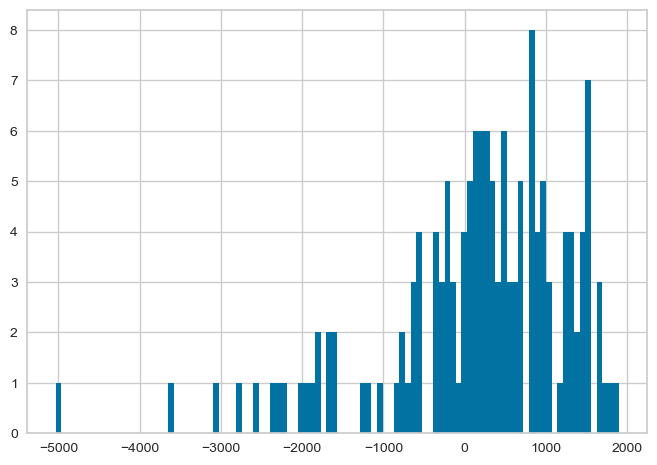

In [361]:
(results['cnt'] - results['cnt_pred']).hist(bins=100)


In [363]:
r2_score(results['cnt'], results['cnt_pred'])


ValueError: Input contains NaN.

In [ ]:
results['error'] = (results['cnt'] - results['cnt_pred'])


In [366]:
results = results.drop('index', axis=1)


In [368]:
"""
import pandas as pd
from datetime import date, timedelta

def get_holidays(year):
    # New Year's Day: January 1
    new_year = pd.Timestamp(date(year, 1, 1))
    
    # Valentine's Day: February 14
    valentines_day = pd.Timestamp(date(year, 2, 14))
    
    # Mother's Day: second Sunday in May
    may_first = date(year, 5, 1)
    first_sunday_may = may_first + timedelta(days=(6 - may_first.weekday()) % 7)
    mothers_day = pd.Timestamp(first_sunday_may + timedelta(days=7))
    
    # Father's Day: third Sunday in June
    june_first = date(year, 6, 1)
    first_sunday_june = june_first + timedelta(days=(6 - june_first.weekday()) % 7)
    fathers_day = pd.Timestamp(first_sunday_june + timedelta(days=14))
    
    # Independence Day: July 4
    independence_day = pd.Timestamp(date(year, 7, 4))
    
    # Halloween: October 31
    halloween = pd.Timestamp(date(year, 10, 31))
    
    # Veterans Day: November 11
    veterans_day = pd.Timestamp(date(year, 11, 11))
    
    # Labor Day: first Monday in September
    sept_first = date(year, 9, 1)
    labor_day = pd.Timestamp(sept_first + timedelta(days=(0 - sept_first.weekday()) % 7))
    
    # Easter: Anonymous Gregorian algorithm
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    easter = pd.Timestamp(date(year, month, day))
    
    
    return [
        veterans_day,
        fathers_day,
        mothers_day,
        new_year,
        independence_day,
        halloween,
        easter,
        valentines_day,
        labor_day
    ]

holiday_datetimes = get_holidays(2012)
print(holiday_datetimes)
"""


"\nimport pandas as pd\nfrom datetime import date, timedelta\n\ndef get_holidays(year):\n    # New Year's Day: January 1\n    new_year = pd.Timestamp(date(year, 1, 1))\n    \n    # Valentine's Day: February 14\n    valentines_day = pd.Timestamp(date(year, 2, 14))\n    \n    # Mother's Day: second Sunday in May\n    may_first = date(year, 5, 1)\n    first_sunday_may = may_first + timedelta(days=(6 - may_first.weekday()) % 7)\n    mothers_day = pd.Timestamp(first_sunday_may + timedelta(days=7))\n    \n    # Father's Day: third Sunday in June\n    june_first = date(year, 6, 1)\n    first_sunday_june = june_first + timedelta(days=(6 - june_first.weekday()) % 7)\n    fathers_day = pd.Timestamp(first_sunday_june + timedelta(days=14))\n    \n    # Independence Day: July 4\n    independence_day = pd.Timestamp(date(year, 7, 4))\n    \n    # Halloween: October 31\n    halloween = pd.Timestamp(date(year, 10, 31))\n    \n    # Veterans Day: November 11\n    veterans_day = pd.Timestamp(date(year, 1

In [237]:
results.loc[results['cnt'] < 1000]


,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,year_month,time_idx,mnth_sin,mnth_cos,cnt_lag2,hum_lag2,atemp_lag2,cnt_roll3,cnt,cnt_pred,error
242,668,2012-10-29,4,1,10,0,1.0,1,3,0.439400,0.880000,0.358200,2012-10,667,-8.660254e-01,0.5,7852.0,0.720000,0.515133,7551.666667,22,5020.026816,-4998.026816
298,724,2012-12-24,1,1,12,0,1.0,1,2,0.258900,0.791304,0.077230,2012-12,723,-2.449294e-16,1.0,1749.0,0.441250,0.236113,3166.666667,920,2745.441351,-1825.441351
300,726,2012-12-26,1,1,12,0,3.0,1,3,0.220333,0.823333,0.316546,2012-12,725,-2.449294e-16,1.0,920.0,0.791304,0.258900,1485.333333,441,1786.119387,-1345.119387


In [239]:
results.hvplot.line(x='dteday', y='error') * hv.Overlay([hv.VLine(h) for h in holiday_datetimes])


:Overlay
   .Curve.I    :Curve   [dteday]   (error)
   .VLine.I    :VLine   [x,y]
   .VLine.II   :VLine   [x,y]
   .VLine.III  :VLine   [x,y]
   .VLine.IV   :VLine   [x,y]
   .VLine.V    :VLine   [x,y]
   .VLine.VI   :VLine   [x,y]
   .VLine.VII  :VLine   [x,y]
   .VLine.VIII :VLine   [x,y]
   .VLine.IX   :VLine   [x,y]

In [241]:
results.head(10)


,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,year_month,time_idx,mnth_sin,mnth_cos,cnt_lag2,hum_lag2,atemp_lag2,cnt_roll3,cnt,cnt_pred,error
0,425,2012-03-01,1,1,3,0,4.0,1,1,0.475371,0.615417,0.226987,2012-03,425,1.0,6.123234e-17,4363.0,0.395833,0.353525,4024.666667,4990,4611.326557,378.673443
1,426,2012-03-02,1,1,3,0,5.0,1,2,0.359842,0.657083,0.144904,2012-03,426,1.0,6.123234e-17,1834.0,0.804783,0.348470,3506.333333,3194,3331.405701,-137.405701
2,427,2012-03-03,1,1,3,0,6.0,0,2,0.413492,0.621250,0.161079,2012-03,427,1.0,6.123234e-17,4990.0,0.615417,0.475371,3729.000000,4066,3650.686325,415.313675
3,428,2012-03-04,1,1,3,0,0.0,0,1,0.303021,0.403333,0.334571,2012-03,428,1.0,6.123234e-17,3194.0,0.657083,0.359842,3339.333333,3423,3749.014541,-326.014541
4,429,2012-03-05,1,1,3,0,1.0,1,1,0.241171,0.506250,0.228858,2012-03,429,1.0,6.123234e-17,4066.0,0.621250,0.413492,4083.333333,3333,3770.897282,-437.897282
5,430,2012-03-06,1,1,3,0,2.0,1,1,0.255042,0.456667,0.200875,2012-03,430,1.0,6.123234e-17,3423.0,0.403333,0.303021,3561.000000,3956,3835.096351,120.903649
6,431,2012-03-07,1,1,3,0,3.0,1,1,0.385100,0.513333,0.345779,2012-03,431,1.0,6.123234e-17,3333.0,0.506250,0.241171,3607.333333,4916,4444.875356,471.124644
7,432,2012-03-08,1,1,3,0,4.0,1,1,0.524604,0.567500,0.441563,2012-03,432,1.0,6.123234e-17,3956.0,0.456667,0.255042,3570.666667,5382,4935.731952,446.268048
8,433,2012-03-09,1,1,3,0,5.0,1,2,0.397083,0.407083,0.414800,2012-03,433,1.0,6.123234e-17,4916.0,0.513333,0.385100,4068.333333,4569,4031.491676,537.508324
9,434,2012-03-10,1,1,3,0,6.0,0,1,0.277767,0.350417,0.225750,2012-03,434,1.0,6.123234e-17,5382.0,0.567500,0.524604,4751.333333,4118,4070.320165,47.679835


In [243]:
results.tail(10)


,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,year_month,time_idx,mnth_sin,mnth_cos,cnt_lag2,hum_lag2,atemp_lag2,cnt_roll3,cnt,cnt_pred,error
296,722,2012-12-22,1,1,12,0,6.0,0,1,0.236113,0.441250,0.407346,2012-12,721,-2.449294e-16,1.0,4128.0,0.667917,0.335217,4984.000000,1749,4117.728239,-2368.728239
297,723,2012-12-23,1,1,12,0,0.0,0,1,0.259471,0.515417,0.133083,2012-12,722,-2.449294e-16,1.0,3623.0,0.556667,0.301767,4339.333333,1787,3816.183563,-2029.183563
298,724,2012-12-24,1,1,12,0,1.0,1,2,0.258900,0.791304,0.077230,2012-12,723,-2.449294e-16,1.0,1749.0,0.441250,0.236113,3166.666667,920,2745.441351,-1825.441351
299,725,2012-12-25,1,1,12,1,2.0,0,2,0.294465,0.734783,0.168726,2012-12,724,-2.449294e-16,1.0,1787.0,0.515417,0.259471,2386.333333,1013,2445.973713,-1432.973713
300,726,2012-12-26,1,1,12,0,3.0,1,3,0.220333,0.823333,0.316546,2012-12,725,-2.449294e-16,1.0,920.0,0.791304,0.258900,1485.333333,441,1786.119387,-1345.119387
301,727,2012-12-27,1,1,12,0,4.0,1,2,0.226642,0.652917,0.350133,2012-12,726,-2.449294e-16,1.0,1013.0,0.734783,0.294465,1240.000000,2114,2415.734283,-301.734283
302,728,2012-12-28,1,1,12,0,5.0,1,2,0.255046,0.590000,0.155471,2012-12,727,-2.449294e-16,1.0,441.0,0.823333,0.220333,791.333333,3095,2677.845288,417.154712
303,729,2012-12-29,1,1,12,0,6.0,0,2,0.242400,0.752917,0.124383,2012-12,728,-2.449294e-16,1.0,2114.0,0.652917,0.226642,1189.333333,1341,2693.562594,-1352.562594
304,730,2012-12-30,1,1,12,0,0.0,0,1,0.231700,0.483333,0.350754,2012-12,729,-2.449294e-16,1.0,3095.0,0.590000,0.255046,1883.333333,1796,3422.120873,-1626.120873
305,731,2012-12-31,1,1,12,0,1.0,1,2,0.223487,0.577500,0.154846,2012-12,730,-2.449294e-16,1.0,1341.0,0.752917,0.242400,2183.333333,2729,2739.846251,-10.846251


## **EVALUATION**


**ACTUAL VS PREDICTED**


In [247]:
# --- Create DataFrame ---
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

lim_min = 0
lim_max = 9000


In [249]:
# --- Create the Scatter Plot ---
scatter_plot = plot_df.hvplot.scatter(
    x='Actual',
    y='Predicted',
    width=500,
    height=400,
    xlim=(lim_min, lim_max),
    ylim=(lim_min, lim_max),
    title="Actual vs. Predicted",
    grid=True,
    hover_cols=['Actual', 'Predicted'] 
)


line_plot = hv.Curve( ([lim_min, lim_max], [lim_min, lim_max]) ).opts(
    color='red',          
    line_dash='dashed',   
    xlabel='Actual',      
    ylabel='Predicted'
)

final_plot = scatter_plot * line_plot

final_plot


:Overlay
   .Scatter.I :Scatter   [Actual]   (Predicted)
   .Curve.I   :Curve   [x]   (y)

**TEST SET: ACTUAL VS. PREDICTED**


NameError: name 'y_pred_test' is not defined

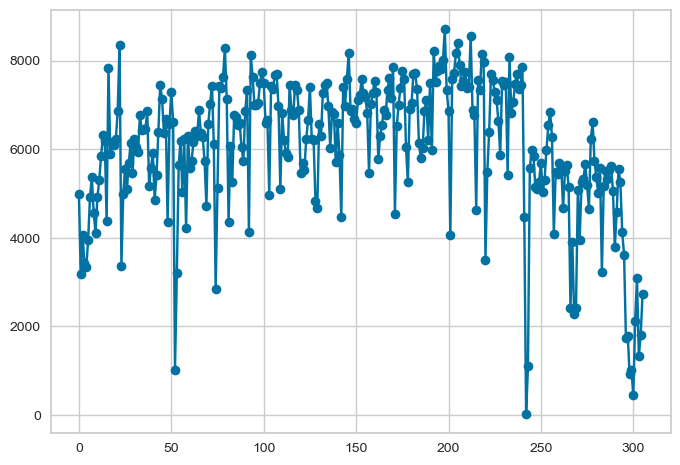

In [252]:
# Make sure you have y_test defined (the actual target values for your test set)
plt.figure()
plt.plot(range(len(y_test)), y_test, marker='o', label='Test Actual')
plt.plot(range(len(y_test)), y_pred_test, marker='x', label='Test Predicted')
plt.title("TEST SET: Actual vs. Predicted")
plt.xlabel("Index (Test Samples)")
plt.ylabel("Target Value")
plt.legend()
plt.show()


**TEST SET RESIDUALS**


In [255]:
# Residuals for the TEST set
residuals_test = y_test - y_pred_test

plt.figure()
plt.scatter(range(len(y_test)), residuals_test, marker='o')
plt.axhline(y=0, color='r', linestyle='--')
plt.title("TEST SET: Residuals")
plt.xlabel("Index (Test Samples)")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()


NameError: name 'y_pred_test' is not defined